<a href="https://colab.research.google.com/github/kelesmerve/iomt-ortaminda-federe-ogrenme-bitirme-projesi/blob/main/federe_mha_poison_savunma_10client.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# BLOK 0-A — ORTAM KURULUMU, DRIVE BAĞLANTISI, MODEL MİMARİSİ
# 10-CLIENT MODEL POISONING & SAVUNMA
# Zehirli clientlar : C02 (Bölge Hastanesi) + C06 (IoMT Ana) — WiFi+MQTT karma
# Savunma           : Trimmed Mean (trim_ratio=0.3 → her uçtan 3 kırp, 4 kalan)
# =============================================================================

import os, gc, math, time, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from google.colab import drive

print("=" * 65)
print("   BLOK 0-A: ORTAM KURULUMU (10 CLIENT POISON & SAVUNMA)")
print("=" * 65)

# ── Drive ──────────────────────────────────────────────────────────────────
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı")

# ── GPU ────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    det = tf.config.experimental.get_device_details(gpus[0])
    gpu_name = det.get('device_name', 'Bilinmiyor')
    print(f"✅ GPU: {gpu_name}")
    if 'H100' in gpu_name or 'A100' in gpu_name:
        mixed_precision.set_global_policy('mixed_bfloat16')
        tf.config.optimizer.set_jit(True)
        print("✅ Mixed Precision: bfloat16 | XLA: AKTİF")
    else:
        mixed_precision.set_global_policy('float32')
        print("✅ Precision: float32")
else:
    print("⚠️  GPU bulunamadı — CPU ile devam ediliyor")

# ── Global Sabitler ────────────────────────────────────────────────────────
ROOT_PATH   = '/content/drive/MyDrive/wifi_mqtt'
SAVE_DIR    = '/content/drive/MyDrive/federe_mha_lstm_10client_outputs'
RESULTS_DIR = f'{SAVE_DIR}/poison_savunma_sonuclari'
MODEL_PATH  = f'{SAVE_DIR}/federe_mha_lstm_10client_best.keras'

os.makedirs(RESULTS_DIR, exist_ok=True)

TIME_STEPS    = 20
PCA_VARIANCE  = 0.95
SEED          = 42
TEST_SIZE     = 0.20
BATCH_SIZE    = 512
LEARNING_RATE = 0.001
NUM_CLIENTS   = 10

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── NaN-Safe Loss ──────────────────────────────────────────────────────────
def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# ── Transformer Bloğu ──────────────────────────────────────────────────────
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim,
                               dropout_rate, name_prefix=""):
    attn_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads,
        dropout=dropout_rate, name=f"{name_prefix}_mha"
    )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])
    ff_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu', name=f"{name_prefix}_ff1")(ff_input)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])
    return x

# ── Model Mimarisi (10-client eğitim notebook'uyla birebir aynı) ───────────
def build_model(time_steps, pca_components):
    inputs = Input(shape=(time_steps, pca_components), dtype='float32', name='input')

    # ENCODER
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu',
               name='conv_local')(inputs)
    x = Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal'),
        name='bilstm_encoder'
    )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)
    x = transformer_encoder_block(x, embed_dim=256, num_heads=4, ff_dim=512,
                                   dropout_rate=0.1, name_prefix="enc_transformer")
    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal',
                       name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5, name='bottleneck_ln')(encoder_out)
    x = transformer_encoder_block(encoder_out, embed_dim=64, num_heads=4,
                                   ff_dim=128, dropout_rate=0.1,
                                   name_prefix="bottleneck_transformer")

    # DECODER
    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)
    x = transformer_encoder_block(x, embed_dim=128, num_heads=4, ff_dim=256,
                                   dropout_rate=0.1, name_prefix="dec_transformer")
    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)
    x = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='Federe_MHA_LSTM_Autoencoder_10Client')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )
    return model

print("\n✅ build_model() tanımlandı (10-client mimarisiyle birebir)")
print("\n" + "=" * 65)
print("   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GEÇİN")
print("=" * 65)


   BLOK 0-A: ORTAM KURULUMU (10 CLIENT POISON & SAVUNMA)
Mounted at /content/drive
✅ Google Drive bağlandı
✅ GPU: NVIDIA A100-SXM4-80GB
✅ Mixed Precision: bfloat16 | XLA: AKTİF

✅ build_model() tanımlandı (10-client mimarisiyle birebir)

   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GEÇİN


In [2]:
# =============================================================================
# BLOK 0-B — SCALER/PCA/MODEL YÜKLEME + 10 CLIENT DATASETS + X_normal/X_attack
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 65)
print("   BLOK 0-B: DRIVE'DAN YÜKLEME + 10-CLIENT VERİ HAZIRLAMA")
print("=" * 65)

# ── 1. Scaler ve PCA ───────────────────────────────────────────────────────
scaler_path = f'{SAVE_DIR}/federe_mha_scaler.pkl'
pca_path    = f'{SAVE_DIR}/federe_mha_pca.pkl'

if os.path.exists(scaler_path) and os.path.exists(pca_path):
    scaler = joblib.load(scaler_path)
    pca    = joblib.load(pca_path)
    PCA_COMPONENTS  = pca.n_components_
    FEATURE_COLUMNS = list(scaler.feature_names_in_)
    print(f"✅ Scaler yüklendi — {len(FEATURE_COLUMNS)} özellik")
    print(f"✅ PCA yüklendi   — {PCA_COMPONENTS} bileşen")
else:
    raise FileNotFoundError(
        f"❌ Scaler/PCA bulunamadı: {scaler_path}\n"
        "   10-client eğitim notebook'unu önce çalıştırın."
    )

# ── 2. Normal veriden 10-client bölünmesi (eğitimle birebir aynı) ──────────
print("\n📂 Normal (profiling) dosyaları taranıyor...")

all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> {len(all_benign_files)} dosya bulundu")

wifi_files, mqtt_files = [], []
for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

if len(mqtt_files) < 2:
    print("   ⚠️ İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...")
    mid = len(all_benign_files) // 2
    wifi_files = all_benign_files[:mid]
    mqtt_files = all_benign_files[mid:]

print(f"   -> WiFi dosya: {len(wifi_files)} | MQTT dosya: {len(mqtt_files)}")

def load_client_df(file_list):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except:
            pass
    return pd.concat(dfs, ignore_index=True)

df_wifi_all = load_client_df(wifi_files)
df_mqtt_all = load_client_df(mqtt_files)
print(f"   -> WiFi havuzu: {df_wifi_all.shape} | MQTT havuzu: {df_mqtt_all.shape}")

# ── 10-client Non-IID bölünme (eğitim notebook'uyla birebir) ───────────────
# WiFi → C01(%40) C02(%20) C03(%20) C04(%12) C05(%8 → %60'ı C05, %40'ı karma)
w_total   = len(df_wifi_all)
w_c1_end  = int(w_total * 0.40)
w_c2_end  = w_c1_end  + int(w_total * 0.20)
w_c3_end  = w_c2_end  + int(w_total * 0.20)
w_c4_end  = w_c3_end  + int(w_total * 0.12)
wifi_c5_raw = df_wifi_all.iloc[w_c4_end:]
w_c5_cut    = int(len(wifi_c5_raw) * 0.60)

df_c1 = df_wifi_all.iloc[:w_c1_end]
df_c2 = df_wifi_all.iloc[w_c1_end:w_c2_end]
df_c3 = df_wifi_all.iloc[w_c2_end:w_c3_end]
df_c4 = df_wifi_all.iloc[w_c3_end:w_c4_end]
df_c5 = wifi_c5_raw.iloc[:w_c5_cut]
wifi_leftover = wifi_c5_raw.iloc[w_c5_cut:]

# MQTT → C06(%50) C07(%30) C08(%20 → %60'ı C08, %40'ı karma)
m_total   = len(df_mqtt_all)
m_c6_end  = int(m_total * 0.50)
m_c7_end  = m_c6_end + int(m_total * 0.30)
mqtt_c8_raw = df_mqtt_all.iloc[m_c7_end:]
m_c8_cut    = int(len(mqtt_c8_raw) * 0.60)

df_c6 = df_mqtt_all.iloc[:m_c6_end]
df_c7 = df_mqtt_all.iloc[m_c6_end:m_c7_end]
df_c8 = mqtt_c8_raw.iloc[:m_c8_cut]
mqtt_leftover = mqtt_c8_raw.iloc[m_c8_cut:]

# Karma → C09(%60) C10(%40)
karma_pool = pd.concat([wifi_leftover, mqtt_leftover], ignore_index=True)
karma_cut  = int(len(karma_pool) * 0.60)
df_c9  = karma_pool.iloc[:karma_cut]
df_c10 = karma_pool.iloc[karma_cut:]

client_dfs = [
    (df_c1,  "C01_Hastane"),
    (df_c2,  "C02_BolgeH"),
    (df_c3,  "C03_SaglikA"),
    (df_c4,  "C04_SaglikB"),
    (df_c5,  "C05_Eczane"),
    (df_c6,  "C06_IoMT"),
    (df_c7,  "C07_SensorA"),
    (df_c8,  "C08_Sensor"),
    (df_c9,  "C09_Ambulans"),
    (df_c10, "C10_Edge"),
]
del df_wifi_all, df_mqtt_all, karma_pool; gc.collect()

print(f"\n{'Client':<18} {'Satır':>10} {'Kolon':>7}")
print("-" * 38)
for df, name in client_dfs:
    print(f"  {name:<16}: {df.shape[0]:>8,}  {df.shape[1]:>6}")

# ── Sequence oluşturma ─────────────────────────────────────────────────────
def create_sequences_fast(data, time_steps):
    n       = data.shape[0] - time_steps
    shape   = (n, time_steps, data.shape[1])
    strides = (data.strides[0], data.strides[0], data.strides[1])
    return np.array(
        np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides),
        dtype=np.float32
    )

AUTOTUNE = tf.data.AUTOTUNE

def make_client_dataset(df, name):
    scaled = scaler.transform(df).astype(np.float32)
    pca_t  = pca.transform(scaled).astype(np.float32)
    seqs   = create_sequences_fast(pca_t, TIME_STEPS)
    split  = int(len(seqs) * (1 - TEST_SIZE))
    X_tr, X_val = seqs[:split], seqs[split:]

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
        .cache().shuffle(15000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, X_val))
        .cache().batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)
    )
    print(f"   -> [{name:<14}] train={len(X_tr):>8,} | val={len(X_val):>7,}")
    return {"name": name, "train": train_ds, "val": val_ds,
            "n_train": len(X_tr), "n_val": len(X_val)}

print("\n⚡ 10 Client pipeline'ları oluşturuluyor...")
CLIENT_DATASETS = []
for df, name in client_dfs:
    CLIENT_DATASETS.append(make_client_dataset(df, name))
del client_dfs; gc.collect()

# ── Baseline modeli yükle ──────────────────────────────────────────────────
print(f"\n📥 10-client modeli yükleniyor: {MODEL_PATH}")
tf.keras.backend.clear_session(); gc.collect()

baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"✅ Baseline model yüklendi — {baseline_model.count_params():,} parametre")

INITIAL_WEIGHTS = [w.copy() for w in baseline_model.get_weights()]
joblib.dump(INITIAL_WEIGHTS, f'{RESULTS_DIR}/initial_weights_10client.pkl')
print(f"✅ INITIAL_WEIGHTS saklandı — {len(INITIAL_WEIGHTS)} katman")

# ── X_normal ───────────────────────────────────────────────────────────────
print("\n📊 X_normal hazırlanıyor (val setlerinden)...")
normal_parts = []
for cd in CLIENT_DATASETS:
    for bx, _ in cd["val"]:
        normal_parts.append(bx.numpy())
X_normal_full = np.concatenate(normal_parts, axis=0)
del normal_parts; gc.collect()

MAX_EVAL = 30_000
if len(X_normal_full) > MAX_EVAL:
    idx = np.random.choice(len(X_normal_full), MAX_EVAL, replace=False)
    X_normal = X_normal_full[idx]
else:
    X_normal = X_normal_full
del X_normal_full; gc.collect()
print(f"   -> X_normal shape: {X_normal.shape}")

# ── X_attack ───────────────────────────────────────────────────────────────
print("\n📂 Attack dosyaları taranıyor...")
attack_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and any(
            kw in root.lower()
            for kw in ['attack', 'attacks', 'saldiri', 'anomaly', 'malicious', 'intrusion']
        ):
            attack_files.append(os.path.join(root, file))

print(f"   -> Bulunan attack dosyası: {len(attack_files)}")

if attack_files:
    atk_dfs = []
    for f in attack_files:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            atk_dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ Atlandı: {os.path.basename(f)}")

    df_attack     = pd.concat(atk_dfs, ignore_index=True)
    del atk_dfs; gc.collect()
    scaled_atk    = scaler.transform(df_attack).astype(np.float32)
    pca_atk       = pca.transform(scaled_atk).astype(np.float32)
    X_attack_full = create_sequences_fast(pca_atk, TIME_STEPS)
    del df_attack, scaled_atk, pca_atk; gc.collect()

    if len(X_attack_full) > MAX_EVAL:
        idx = np.random.choice(len(X_attack_full), MAX_EVAL, replace=False)
        X_attack = X_attack_full[idx]
    else:
        X_attack = X_attack_full
    del X_attack_full; gc.collect()
    ATTACK_DATA_AVAILABLE = True
    print(f"✅ X_attack shape: {X_attack.shape}  (gerçek saldırı verisi)")
else:
    print("⚠️  Attack dosyası bulunamadı → sentetik saldırı üretiliyor")
    np.random.seed(42)
    X_attack = X_normal + 3.0 * np.random.randn(*X_normal.shape).astype(np.float32)
    ATTACK_DATA_AVAILABLE = False
    print(f"   -> X_attack shape: {X_attack.shape}  (sentetik — gürültü x3)")

print(f"\n📋 ÖZET:")
print(f"   PCA_COMPONENTS  : {PCA_COMPONENTS}")
print(f"   CLIENT sayısı   : {len(CLIENT_DATASETS)}")
print(f"   X_normal shape  : {X_normal.shape}")
print(f"   X_attack shape  : {X_attack.shape}")
print(f"   Attack verisi   : {'GERÇEK' if ATTACK_DATA_AVAILABLE else 'SENTETİK ⚠️'}")

print("\n" + "=" * 65)
print("   BLOK 0-B TAMAMLANDI — BLOK 1'E GEÇİN")
print("=" * 65)


   BLOK 0-B: DRIVE'DAN YÜKLEME + 10-CLIENT VERİ HAZIRLAMA
✅ Scaler yüklendi — 40 özellik
✅ PCA yüklendi   — 20 bileşen

📂 Normal (profiling) dosyaları taranıyor...
   -> 42 dosya bulundu
   ⚠️ İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...
   -> WiFi dosya: 21 | MQTT dosya: 21
   -> WiFi havuzu: (131133, 40) | MQTT havuzu: (258823, 40)

Client                  Satır   Kolon
--------------------------------------
  C01_Hastane     :   52,453      40
  C02_BolgeH      :   26,226      40
  C03_SaglikA     :   26,226      40
  C04_SaglikB     :   15,735      40
  C05_Eczane      :    6,295      40
  C06_IoMT        :  129,411      40
  C07_SensorA     :   77,646      40
  C08_Sensor      :   31,059      40
  C09_Ambulans    :   14,943      40
  C10_Edge        :    9,962      40

⚡ 10 Client pipeline'ları oluşturuluyor...
   -> [C01_Hastane   ] train=  41,946 | val= 10,487
   -> [C02_BolgeH    ] train=  20,964 | val=  5,242
   -> [C03_SaglikA   ] train=  20,964 | val=  5,2

In [3]:
# =============================================================================
# BLOK 1 — YAPILANDIRMA
# Zehirli: C02 (indeks 1) + C06 (indeks 5) — WiFi+MQTT karma seçim
# Savunma: Trimmed Mean trim_ratio=0.3 → her uçtan 3 kırp → 4 client kalır
# =============================================================================

ALPHA_POISON               = 2.0
COMPROMISED_CLIENT_INDICES = [1, 5]   # C02 (Bölge Hastanesi) + C06 (IoMT Ana)
EVAL_ROUNDS   = 10
EVAL_EPOCHS   = 3
PATIENCE      = 5
TRIM_RATIO    = 0.3    # 10 clienttan her uçtan 3 kırp → 4 kalan
NOISE_SCALE   = 1e-4

# ── Threshold — PR optimize (10-client eğitiminden gelen) ──────────────────
thresh_pr_path = f'{SAVE_DIR}/federe_mha_threshold_pr_10client.pkl'
thresh_f1_path = f'{SAVE_DIR}/federe_mha_threshold_f1_10client.pkl'

if os.path.exists(thresh_pr_path):
    FIXED_THRESHOLD = joblib.load(thresh_pr_path)
    print(f"[OK] FIXED_THRESHOLD (PR-optimize): {FIXED_THRESHOLD:.5f}")
elif os.path.exists(thresh_f1_path):
    FIXED_THRESHOLD = joblib.load(thresh_f1_path)
    print(f"[OK] FIXED_THRESHOLD (F1-optimize): {FIXED_THRESHOLD:.5f}")
else:
    print("⚠️  Threshold pkl bulunamadı — baseline modelinden hesaplanıyor...")
    err_n_t = reconstruction_error(baseline_model, X_normal)
    FIXED_THRESHOLD = float(np.percentile(err_n_t, 95))
    print(f"   -> p95 threshold: {FIXED_THRESHOLD:.5f}")

# Hızlı kontrol
def reconstruction_error(model, X, batch_size=512):
    ds    = tf.data.Dataset.from_tensor_slices(X).batch(batch_size).prefetch(2)
    preds = model.predict(ds, verbose=0)
    return np.mean(np.abs(X - preds), axis=(1, 2))

err_n_check = reconstruction_error(baseline_model, X_normal)
err_a_check = reconstruction_error(baseline_model, X_attack)
print(f"     Normal FP  : %{(err_n_check > FIXED_THRESHOLD).mean()*100:.2f}")
print(f"     Attack TP  : %{(err_a_check > FIXED_THRESHOLD).mean()*100:.2f}")

# ── Client bilgi haritası ──────────────────────────────────────────────────
client_info_map = {
    0: "C01 Büyük Hastane   (WiFi %40  — DÜRÜST)",
    1: "C02 Bölge Hastanesi (WiFi %20  — ZEHİRLİ)",
    2: "C03 Sağlık Ocağı A  (WiFi %20  — DÜRÜST)",
    3: "C04 Sağlık Ocağı B  (WiFi %12  — DÜRÜST)",
    4: "C05 Eczane          (WiFi %8   — DÜRÜST)",
    5: "C06 IoMT Ana        (MQTT %50  — ZEHİRLİ)",
    6: "C07 Sensör Kümesi   (MQTT %30  — DÜRÜST)",
    7: "C08 Tekil Sensör    (MQTT %20  — DÜRÜST)",
    8: "C09 Ambulans        (Karma %60 — DÜRÜST)",
    9: "C10 Edge Router     (Karma %40 — DÜRÜST)",
}
print("\n📋 CLIENT DURUMU:")
for idx, desc in client_info_map.items():
    marker = " ← SALDIRGAN" if idx in COMPROMISED_CLIENT_INDICES else ""
    print(f"   [{idx}] {desc}{marker}")

n_trim = int(NUM_CLIENTS * TRIM_RATIO)   # 10 * 0.3 = 3
n_keep = NUM_CLIENTS - 2 * n_trim        # 10 - 6   = 4
print(f"\n  Alpha           : {ALPHA_POISON}")
print(f"  Zehirli client  : {[i+1 for i in COMPROMISED_CLIENT_INDICES]} (C02 + C06)")
print(f"  Rounds          : {EVAL_ROUNDS}")
print(f"  Trim ratio      : {TRIM_RATIO}  → her uçtan {n_trim} kırp → {n_keep} client kalır")


[OK] FIXED_THRESHOLD (PR-optimize): 0.20755
     Normal FP  : %14.93
     Attack TP  : %97.05

📋 CLIENT DURUMU:
   [0] C01 Büyük Hastane   (WiFi %40  — DÜRÜST)
   [1] C02 Bölge Hastanesi (WiFi %20  — ZEHİRLİ) ← SALDIRGAN
   [2] C03 Sağlık Ocağı A  (WiFi %20  — DÜRÜST)
   [3] C04 Sağlık Ocağı B  (WiFi %12  — DÜRÜST)
   [4] C05 Eczane          (WiFi %8   — DÜRÜST)
   [5] C06 IoMT Ana        (MQTT %50  — ZEHİRLİ) ← SALDIRGAN
   [6] C07 Sensör Kümesi   (MQTT %30  — DÜRÜST)
   [7] C08 Tekil Sensör    (MQTT %20  — DÜRÜST)
   [8] C09 Ambulans        (Karma %60 — DÜRÜST)
   [9] C10 Edge Router     (Karma %40 — DÜRÜST)

  Alpha           : 2.0
  Zehirli client  : [2, 6] (C02 + C06)
  Rounds          : 10
  Trim ratio      : 0.3  → her uçtan 3 kırp → 4 client kalır


In [8]:
# =============================================================================
# BLOK 2 — YARDIMCI FONKSİYONLAR
# =============================================================================

# ── Cosine LR ────────────────────────────────────────────────────────────────
def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

# ── Model Poisoning ───────────────────────────────────────────────────────────
def targeted_model_poisoning(honest_weights, global_weights,
                              alpha=ALPHA_POISON, noise_scale=NOISE_SCALE):
    """
    Gradient tersine çevirme saldırısı:
    poisoned = global - alpha * (honest - global) + gürültü
    Model güncellemesini tersine çevirir ve büyütür.
    """
    poisoned = []
    for h, g in zip(honest_weights, global_weights):
        pseudo_grad = h - g
        p = g - alpha * pseudo_grad
        noise = np.random.normal(
            0.0, noise_scale * (np.std(g) + 1e-8), p.shape
        )
        poisoned.append((p + noise).astype(np.float32))
    return poisoned

# ── Weighted FedAvg ───────────────────────────────────────────────────────────
def weighted_fed_avg(weights_list, n_samples_list):
    total = sum(n_samples_list)
    fracs = [n / total for n in n_samples_list]
    return [
        np.sum([f * w for f, w in zip(fracs, layer_ws)], axis=0)
        for layer_ws in zip(*weights_list)
    ]

# ── Trimmed Mean (10 client, trim_ratio=0.3) ──────────────────────────────────
def trimmed_mean_aggregation(weights_list, trim_ratio=TRIM_RATIO):
    """
    10 client, trim_ratio=0.3:
      n_trim = floor(10 * 0.3) = 3  → her uçtan 3 client kırpılır
      n_keep = 10 - 2*3 = 4         → en yakın 4 clientın ortalaması alınır

    Zehirli C02 (indeks 1) ve C06 (indeks 5) büyük olasılıkla
    uç değer olarak kırpılır ve global modeli bozamazlar.
    """
    n_clients = len(weights_list)
    n_trim    = max(1, int(n_clients * trim_ratio))   # 3
    n_keep    = n_clients - 2 * n_trim                # 4

    if n_keep < 1:
        print(f"  [UYARI] trim_ratio çok büyük, n_keep={n_keep} → FedAvg'e düşüldü")
        return weighted_fed_avg(weights_list, [1] * n_clients)

    aggregated = []
    for layer_idx in range(len(weights_list[0])):
        layer_stack  = np.stack(
            [weights_list[c][layer_idx] for c in range(n_clients)], axis=0
        )
        sorted_stack = np.sort(layer_stack, axis=0)
        trimmed      = sorted_stack[n_trim: n_trim + n_keep]
        aggregated.append(np.mean(trimmed, axis=0).astype(np.float32))
    return aggregated

# ── Reconstruction Error ──────────────────────────────────────────────────────
def reconstruction_error(model, X, batch_size=512):
    ds    = tf.data.Dataset.from_tensor_slices(X).batch(batch_size).prefetch(2)
    preds = model.predict(ds, verbose=0)
    return np.mean(np.abs(X - preds), axis=(1, 2))

# ── Metrik Hesaplama ──────────────────────────────────────────────────────────
def compute_metrics(err_normal, err_attack, threshold=None):
    if threshold is None:
        threshold = FIXED_THRESHOLD
    all_scores = np.concatenate([err_normal, err_attack])
    all_labels = np.concatenate([
        np.zeros(len(err_normal), dtype=int),
        np.ones(len(err_attack),  dtype=int)
    ])
    y_pred = (all_scores > threshold).astype(int)
    return {
        'threshold' : threshold,
        'accuracy'  : accuracy_score(all_labels, y_pred),
        'precision' : precision_score(all_labels, y_pred, zero_division=0),
        'recall'    : recall_score(all_labels, y_pred, zero_division=0),
        'f1'        : f1_score(all_labels, y_pred, zero_division=0),
        'auc'       : roc_auc_score(all_labels, all_scores),
        'y_true'    : all_labels,
        'y_pred'    : y_pred,
        'y_score'   : all_scores,
        'err_normal': err_normal,
        'err_attack': err_attack,
    }

# ── Tek Client Eğitimi ────────────────────────────────────────────────────────
def train_one_client(global_weights, client_info, local_epochs, lr):
    tf.keras.backend.clear_session()
    local_model = build_model(TIME_STEPS, PCA_COMPONENTS)
    local_model.set_weights([w.copy() for w in global_weights])
    local_model.optimizer.learning_rate = lr

    hist = local_model.fit(
        client_info["train"],
        epochs=local_epochs,
        validation_data=client_info["val"],
        verbose=0
    )
    t_loss = hist.history['loss'][-1]
    v_loss = hist.history['val_loss'][-1]
    new_w  = local_model.get_weights()
    del local_model; gc.collect()
    return new_w, t_loss, v_loss

n_trim_actual = int(NUM_CLIENTS * TRIM_RATIO)
n_keep_actual = NUM_CLIENTS - 2 * n_trim_actual
print("[OK] Tüm fonksiyonlar tanımlandı")
print(f"     10 client | Trimmed Mean: her uçtan {n_trim_actual} kırp → {n_keep_actual} clientla ortalama")
print(f"     Zehirli: C02 (idx=1) + C06 (idx=5)")


[OK] Tüm fonksiyonlar tanımlandı
     10 client | Trimmed Mean: her uçtan 3 kırp → 4 clientla ortalama
     Zehirli: C02 (idx=1) + C06 (idx=5)


In [9]:
# =============================================================================
# BLOK 3 — SENARYO ÇALIŞTIRICI (RUNNER)
# =============================================================================

def run_scenario(
    scenario_name,
    initial_weights,
    use_poisoning,
    use_trimmed_mean,
    n_rounds        = EVAL_ROUNDS,
    local_epochs    = EVAL_EPOCHS,
    compromised_idx = COMPROMISED_CLIENT_INDICES,
    trim_ratio      = TRIM_RATIO,
    alpha           = ALPHA_POISON,
    client_datasets = None,
):
    if client_datasets is None:
        client_datasets = CLIENT_DATASETS

    n_clients = len(client_datasets)
    n_trim    = int(n_clients * trim_ratio)       # 3
    n_keep    = n_clients - 2 * n_trim            # 4

    print("\n" + "=" * 65)
    print(f"  SENARYO  : {scenario_name}")
    if use_poisoning:
        print(f"  Zehirleme: [AKTİF] {[i+1 for i in compromised_idx]}. clientlar (C02+C06)")
    else:
        print(f"  Zehirleme: [PASİF] (temiz)")
    if use_trimmed_mean:
        print(f"  Aggreg.  : [SAVUNMA] Trimmed Mean — {n_trim} kırp → {n_keep} kalan")
    else:
        print(f"  Aggreg.  : [SAVUNMASIZ] Weighted FedAvg")
    print(f"  Alpha    : {alpha}  |  Rounds: {n_rounds}  |  Epochs: {local_epochs}")
    print("=" * 65)

    global_weights = [w.copy() for w in initial_weights]
    history = {
        'val_loss'       : [],
        'train_loss'     : [],
        'client_val_loss': [[] for _ in range(n_clients)],
        'round_time_sec' : [],
    }
    best_val     = float('inf')
    best_weights = None
    patience_c   = 0

    print(f"\n  {'Round':>5}  {'Global Val':>11}  {'Delta':>9}  {'LR':>9}  Durum")
    print("  " + "-" * 55)

    for round_idx in range(n_rounds):
        t_start    = time.time()
        current_lr = cosine_lr(round_idx, n_rounds)

        client_weights = []
        client_n       = []
        val_losses     = []
        train_losses   = []
        poisoned_names = []

        for c_idx, client_info in enumerate(client_datasets):
            new_w, t_loss, v_loss = train_one_client(
                global_weights, client_info, local_epochs, current_lr
            )

            # Model poisoning: zehirli clientların ağırlıklarını tersine çevir
            if use_poisoning and (c_idx in compromised_idx):
                new_w = targeted_model_poisoning(
                    honest_weights=new_w,
                    global_weights=global_weights,
                    alpha=alpha,
                    noise_scale=NOISE_SCALE
                )
                poisoned_names.append(client_info["name"])

            client_weights.append(new_w)
            client_n.append(client_info["n_train"])
            val_losses.append(v_loss)
            train_losses.append(t_loss)
            history['client_val_loss'][c_idx].append(v_loss)

        # Aggregasyon
        if use_trimmed_mean:
            global_weights = trimmed_mean_aggregation(client_weights, trim_ratio)
            agg_label      = f"TrimmedMean (n_trim={n_trim}, n_keep={n_keep})"
        else:
            global_weights = weighted_fed_avg(client_weights, client_n)
            agg_label      = "Weighted FedAvg"

        # Global val loss — ağırlıklı ortalama
        total_n    = sum(client_n)
        global_val = sum(v * n / total_n for v, n in zip(val_losses, client_n))
        global_tr  = sum(t * n / total_n for t, n in zip(train_losses, client_n))
        history['val_loss'].append(global_val)
        history['train_loss'].append(global_tr)

        elapsed = time.time() - t_start
        history['round_time_sec'].append(elapsed)

        delta = best_val - global_val
        if global_val < best_val - 1e-5:
            best_val     = global_val
            best_weights = [w.copy() for w in global_weights]
            patience_c   = 0
            status       = "best ✅"
        else:
            patience_c += 1
            status      = f"patience {patience_c}/{PATIENCE}"

        print(f"  {round_idx+1:>5}  {global_val:>11.5f}  {delta:>+9.5f}  "
              f"{current_lr:>9.2e}  {status}")

        if use_poisoning and poisoned_names:
            print(f"         Zehirlenen  : {', '.join(poisoned_names)}  (alpha={alpha})")
        print(f"         Aggregation : {agg_label}")

        if patience_c >= PATIENCE:
            print(f"  [DURDURULDU] Early stopping — {PATIENCE} round iyileşme yok.")
            break

    total_time = sum(history['round_time_sec'])
    print(f"\n  Best val_loss : {best_val:.5f}")
    print(f"  Toplam süre   : {total_time:.1f}s ({total_time/60:.1f} dk)")

    return best_weights, history

print("[OK] run_scenario() tanımlandı")


[OK] run_scenario() tanımlandı


In [10]:
# =============================================================================
# BLOK 4 — BASELINE METRİKLERİ
# =============================================================================

print("=" * 65)
print("   BASELINE METRİKLERİ (10-CLIENT MODELİ)")
print("=" * 65)
print(f"   Threshold : {FIXED_THRESHOLD:.5f}")

# INITIAL_WEIGHTS kontrolü
try:
    _ = INITIAL_WEIGHTS
    print(f"[OK] INITIAL_WEIGHTS hafızada — {len(INITIAL_WEIGHTS)} katman")
except NameError:
    print("[UYARI] INITIAL_WEIGHTS hafızada yok — Drive'dan yükleniyor...")
    INITIAL_WEIGHTS = joblib.load(f'{RESULTS_DIR}/initial_weights_10client.pkl')
    print(f"[OK] INITIAL_WEIGHTS yüklendi — {len(INITIAL_WEIGHTS)} katman")

# Baseline modeli yeniden yükle
tf.keras.backend.clear_session(); gc.collect()
baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"[OK] Baseline model yüklendi — {baseline_model.count_params():,} parametre")

err_n_base       = reconstruction_error(baseline_model, X_normal)
err_a_base       = reconstruction_error(baseline_model, X_attack)
metrics_baseline = compute_metrics(err_n_base, err_a_base)

# Kaydet
joblib.dump(metrics_baseline, f'{RESULTS_DIR}/metrics_baseline_10client.pkl')
baseline_model.save_weights(f'{RESULTS_DIR}/weights_baseline_10client.weights.h5')

print(f"\n  Threshold  : {metrics_baseline['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_baseline['accuracy']*100:.2f}")
print(f"  Precision  : %{metrics_baseline['precision']*100:.2f}")
print(f"  Recall     : %{metrics_baseline['recall']*100:.2f}")
print(f"  F1         : %{metrics_baseline['f1']*100:.2f}")
print(f"  AUC        : {metrics_baseline['auc']:.4f}")
print("\n[OK] Baseline metrikleri ve ağırlıkları kaydedildi.")


   BASELINE METRİKLERİ (10-CLIENT MODELİ)
   Threshold : 0.20755
[OK] INITIAL_WEIGHTS hafızada — 69 katman
[OK] Baseline model yüklendi — 1,475,092 parametre

  Threshold  : 0.20755
  Accuracy   : %91.06
  Precision  : %86.67
  Recall     : %97.05
  F1         : %91.57
  AUC        : 0.9642

[OK] Baseline metrikleri ve ağırlıkları kaydedildi.


In [11]:
# =============================================================================
# BLOK 5 — SALDIRI SENARYOSU
# C02 (indeks 1) + C06 (indeks 5) zehirleniyor | FedAvg (savunmasız)
# =============================================================================

print("\n" + "=" * 65)
print("   SALDIRI SENARYOSU")
print(f"   alpha={ALPHA_POISON} | Zehirli: C02+C06 | FedAvg (SAVUNMASIZ)")
print("=" * 65)

np.random.seed(42)
tf.random.set_seed(42)
t0 = time.time()

attack_weights, hist_attack = run_scenario(
    scenario_name    = f"Saldırı — Model Poisoning alpha={ALPHA_POISON} | FedAvg SAVUNMASIZ",
    initial_weights  = INITIAL_WEIGHTS,
    use_poisoning    = True,
    use_trimmed_mean = False,
    compromised_idx  = COMPROMISED_CLIENT_INDICES,
    alpha            = ALPHA_POISON,
)

print(f"\n[SÜRE] Saldırı süresi: {(time.time()-t0)/60:.1f} dk")

attack_model = build_model(TIME_STEPS, PCA_COMPONENTS)
attack_model.set_weights(attack_weights)

err_n_attack   = reconstruction_error(attack_model, X_normal)
err_a_attack   = reconstruction_error(attack_model, X_attack)
metrics_attack = compute_metrics(err_n_attack, err_a_attack)

# Kaydet
attack_model.save_weights(f'{RESULTS_DIR}/weights_attack_10client.weights.h5')
joblib.dump(hist_attack,    f'{RESULTS_DIR}/hist_attack_10client.pkl')
joblib.dump(metrics_attack, f'{RESULTS_DIR}/metrics_attack_10client.pkl')
print("[OK] Saldırı modeli, history ve metrikleri kaydedildi.")

acc_drop = (metrics_attack['accuracy'] - metrics_baseline['accuracy']) * 100
f1_drop  = (metrics_attack['f1']       - metrics_baseline['f1'])       * 100
auc_drop =  metrics_attack['auc']      - metrics_baseline['auc']

print(f"\n  SALDIRI SONUÇLARI:")
print(f"  {'─'*50}")
print(f"  Threshold  : {metrics_attack['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_attack['accuracy']*100:.2f}  (Delta={acc_drop:+.2f}%)")
print(f"  Precision  : %{metrics_attack['precision']*100:.2f}")
print(f"  Recall     : %{metrics_attack['recall']*100:.2f}")
print(f"  F1         : %{metrics_attack['f1']*100:.2f}  (Delta={f1_drop:+.2f}%)")
print(f"  AUC        : {metrics_attack['auc']:.4f}  (Delta={auc_drop:+.4f})")
print(f"  {'─'*50}")
if acc_drop < -2:
    print("  [SONUÇ] ✅ Saldırı BELİRGİN şekilde etkili!")
else:
    print("  [UYARI] ⚠️ Etkisi sınırlı — alpha veya client sayısını artırın")



   SALDIRI SENARYOSU
   alpha=2.0 | Zehirli: C02+C06 | FedAvg (SAVUNMASIZ)

  SENARYO  : Saldırı — Model Poisoning alpha=2.0 | FedAvg SAVUNMASIZ
  Zehirleme: [AKTİF] [2, 6]. clientlar (C02+C06)
  Aggreg.  : [SAVUNMASIZ] Weighted FedAvg
  Alpha    : 2.0  |  Rounds: 10  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  -------------------------------------------------------
      1      0.04643       +inf   1.00e-03  best ✅
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : Weighted FedAvg
      2      0.04505   +0.00137   9.76e-04  best ✅
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : Weighted FedAvg
      3      0.04656   -0.00151   9.05e-04  patience 1/5
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : Weighted FedAvg
      4      0.08581   -0.04075   7.94e-04  patience 2/5
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : Weighted FedAvg
      5 

In [12]:
# =============================================================================
# BLOK 6 — SAVUNMA SENARYOSU
# C02 + C06 zehirleniyor | Trimmed Mean (trim_ratio=0.3 → 4 kalan)
# =============================================================================

print("\n" + "=" * 65)
print("   SAVUNMA SENARYOSU")
print(f"   alpha={ALPHA_POISON} | Zehirli: C02+C06 | Trimmed Mean (trim=0.3, 4 kalan)")
print("=" * 65)

np.random.seed(42)
tf.random.set_seed(42)
t0 = side = time.time()

defense_weights, hist_defense = run_scenario(
    scenario_name    = f"Savunma — Model Poisoning alpha={ALPHA_POISON} | Trimmed Mean KORUNMALI",
    initial_weights  = INITIAL_WEIGHTS,
    use_poisoning    = True,
    use_trimmed_mean = True,
    compromised_idx  = COMPROMISED_CLIENT_INDICES,
    alpha            = ALPHA_POISON,
)

print(f"\n[SÜRE] Savunma süresi: {(time.time()-t0)/60:.1f} dk")

defense_model = build_model(TIME_STEPS, PCA_COMPONENTS)
defense_model.set_weights(defense_weights)

err_n_defense   = reconstruction_error(defense_model, X_normal)
err_a_defense   = reconstruction_error(defense_model, X_attack)
metrics_defense = compute_metrics(err_n_defense, err_a_defense)

# Kaydet
defense_model.save_weights(f'{RESULTS_DIR}/weights_defense_10client.weights.h5')
joblib.dump(hist_defense,    f'{RESULTS_DIR}/hist_defense_10client.pkl')
joblib.dump(metrics_defense, f'{RESULTS_DIR}/metrics_defense_10client.pkl')
print("[OK] Savunma modeli, history ve metrikleri kaydedildi.")

recovered_acc = (metrics_defense['accuracy'] - metrics_attack['accuracy']) * 100
recovered_f1  = (metrics_defense['f1']       - metrics_attack['f1'])       * 100
gap_baseline  = abs(metrics_defense['accuracy'] - metrics_baseline['accuracy']) * 100

print(f"\n  SAVUNMA SONUÇLARI:")
print(f"  {'─'*50}")
print(f"  Threshold  : {metrics_defense['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_defense['accuracy']*100:.2f}  (+{recovered_acc:.2f}% kurtarıldı)")
print(f"  Precision  : %{metrics_defense['precision']*100:.2f}")
print(f"  Recall     : %{metrics_defense['recall']*100:.2f}")
print(f"  F1         : %{metrics_defense['f1']*100:.2f}  (+{recovered_f1:.2f}% kurtarıldı)")
print(f"  AUC        : {metrics_defense['auc']:.4f}")
print(f"  Baseline'a uzaklık: {gap_baseline:.2f}%  {'[OK] İyi' if gap_baseline < 3 else '[UYARI] Fark var'}")
print(f"  {'─'*50}")
if recovered_acc > 2:
    print("  [SONUÇ] ✅ Savunma BELİRGİN şekilde etkili!")
else:
    print("  [UYARI] ⚠️ Düşük kurtarım — trim_ratio artırılabilir")



   SAVUNMA SENARYOSU
   alpha=2.0 | Zehirli: C02+C06 | Trimmed Mean (trim=0.3, 4 kalan)

  SENARYO  : Savunma — Model Poisoning alpha=2.0 | Trimmed Mean KORUNMALI
  Zehirleme: [AKTİF] [2, 6]. clientlar (C02+C06)
  Aggreg.  : [SAVUNMA] Trimmed Mean — 3 kırp → 4 kalan
  Alpha    : 2.0  |  Rounds: 10  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  -------------------------------------------------------
      1      0.04624       +inf   1.00e-03  best ✅
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : TrimmedMean (n_trim=3, n_keep=4)
      2      0.04482   +0.00142   9.76e-04  best ✅
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : TrimmedMean (n_trim=3, n_keep=4)
      3      0.04386   +0.00096   9.05e-04  best ✅
         Zehirlenen  : C02_BolgeH, C06_IoMT  (alpha=2.0)
         Aggregation : TrimmedMean (n_trim=3, n_keep=4)
      4      0.04348   +0.00038   7.94e-04  best ✅
         Zehirlenen  : C02_BolgeH,


   ANOMALİ TESPİT METRİKLERİ — 3 SENARYO (10 CLIENT)
   alpha=2.0 | Zehirli: C02 (Bölge Hastanesi) + C06 (IoMT Ana)
  Senaryo                                 Acc    Prec  Recall      F1     AUC
  ------------------------------------------------------------------------
  Baseline (Temiz FedAvg)              91.06%  86.67%  97.05%  91.57%  0.9642
  Saldırı (alpha=2.0 | FedAvg)         80.04%  72.65%  96.35%  82.84%  0.9119
  Savunma (alpha=2.0 | TrimMean)       97.20%  97.54%  96.84%  97.19%  0.9831

  Saldırı etkisi   (Accuracy Delta) : -11.02%
  Saldırı etkisi   (F1 Delta)       : -8.73%
  Savunma kurtarım (Accuracy)       : +17.16%
  Savunma kurtarım (F1)             : +14.35%
  Savunma vs Baseline (Acc)         : +6.14%


/tmp/ipykernel_4515/1347514761.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


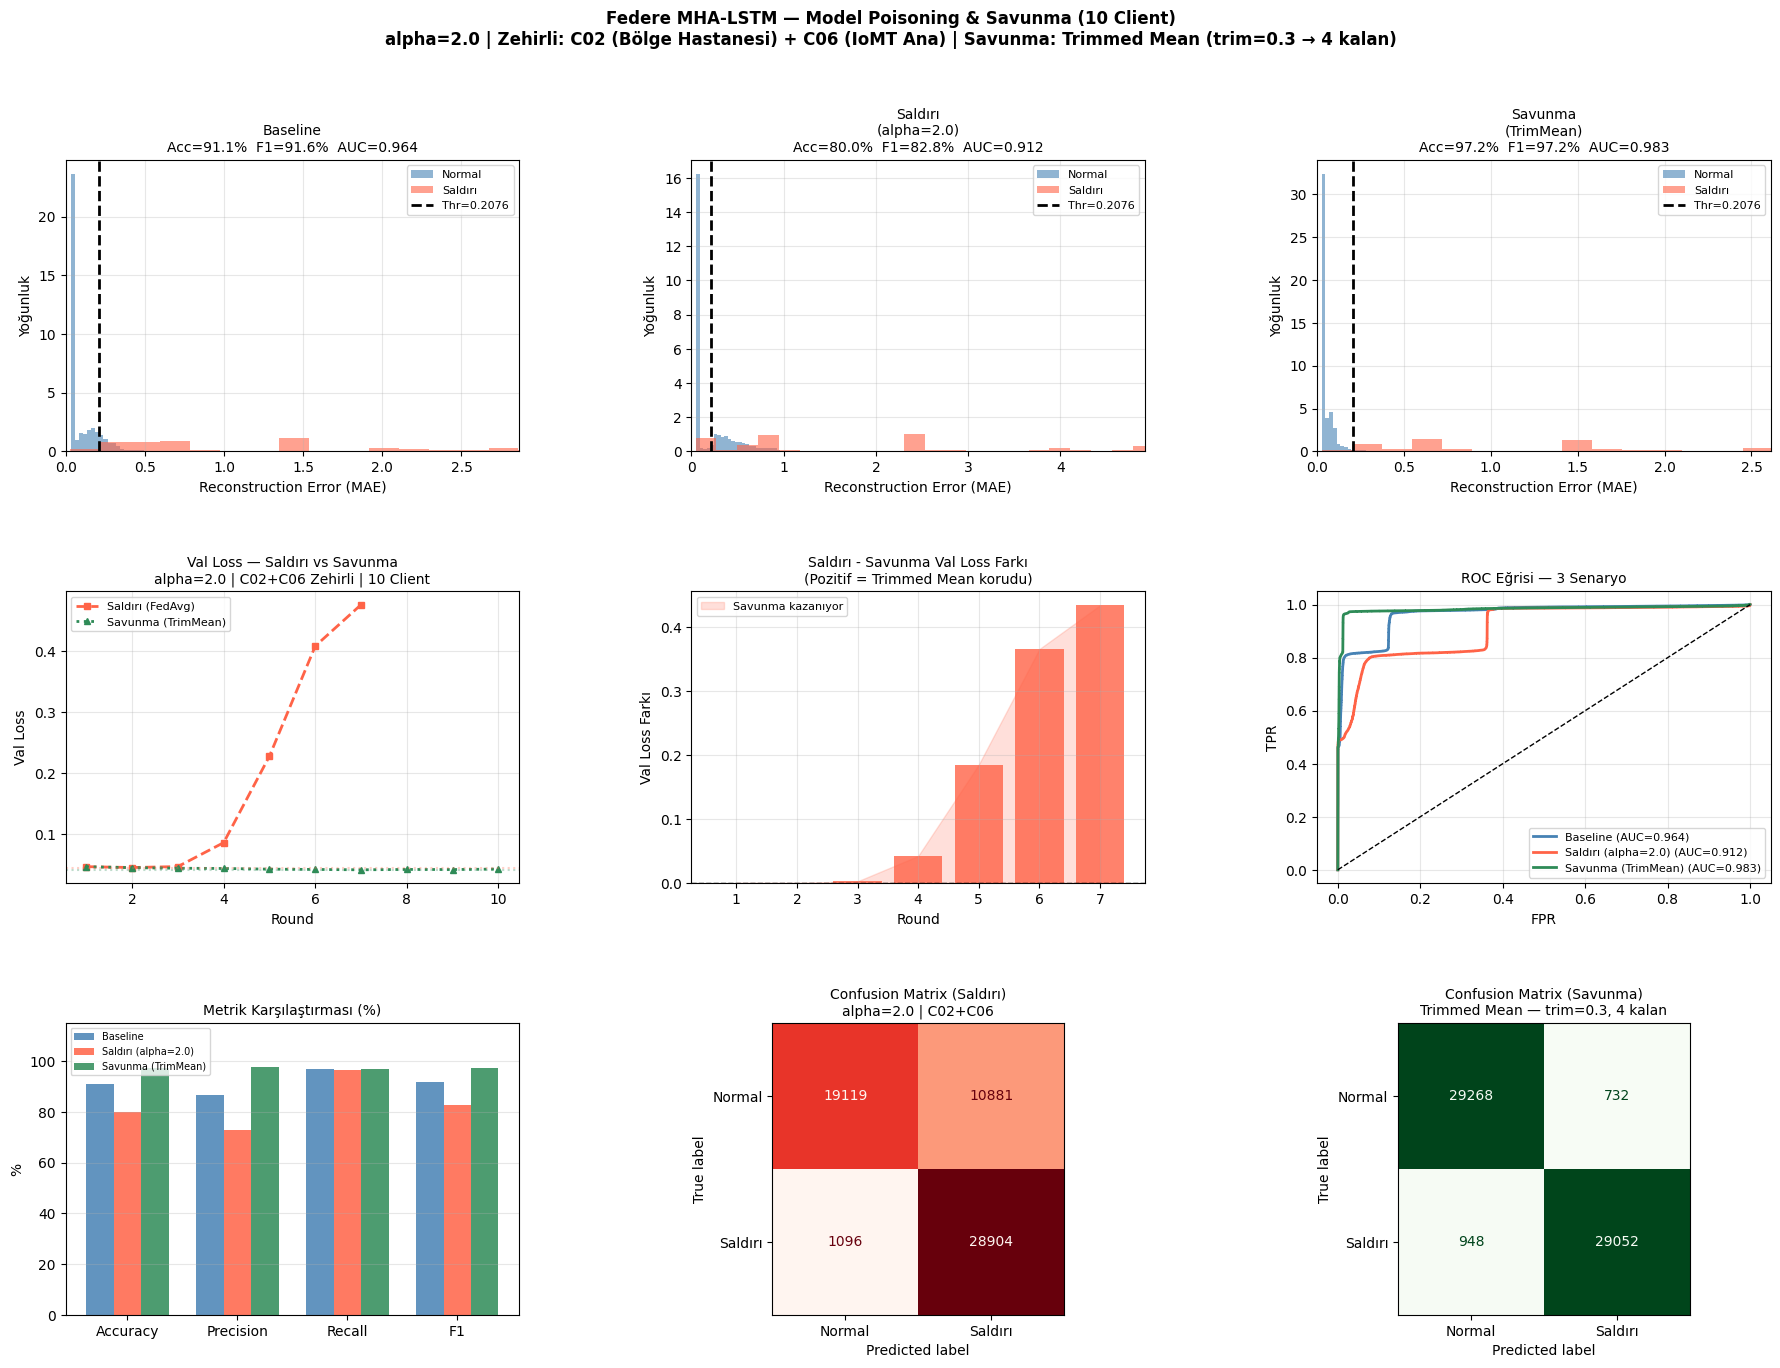

[OK] Grafik kaydedildi: /content/drive/MyDrive/federe_mha_lstm_10client_outputs/poison_savunma_sonuclari/poison_savunma_10client_alpha2.png
[OK] Tüm metrikler kaydedildi: /content/drive/MyDrive/federe_mha_lstm_10client_outputs/poison_savunma_sonuclari/metrics_all_10client.pkl


In [13]:
# =============================================================================
# BLOK 7 — KARŞILAŞTIRMA VE GÖRSELLEŞTİRME
# =============================================================================

print("\n" + "=" * 72)
print("   ANOMALİ TESPİT METRİKLERİ — 3 SENARYO (10 CLIENT)")
print(f"   alpha={ALPHA_POISON} | Zehirli: C02 (Bölge Hastanesi) + C06 (IoMT Ana)")
print("=" * 72)
print(f"  {'Senaryo':<35} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("  " + "-" * 72)

results = {
    "Baseline (Temiz FedAvg)"                    : metrics_baseline,
    f"Saldırı (alpha={ALPHA_POISON} | FedAvg)"    : metrics_attack,
    f"Savunma (alpha={ALPHA_POISON} | TrimMean)"  : metrics_defense,
}

for name, r in results.items():
    print(f"  {name:<35} "
          f"{r['accuracy']*100:>6.2f}% "
          f"{r['precision']*100:>6.2f}% "
          f"{r['recall']*100:>6.2f}% "
          f"{r['f1']*100:>6.2f}% "
          f"{r['auc']:>7.4f}")
print("=" * 72)

b, a, d = metrics_baseline, metrics_attack, metrics_defense
print(f"\n  Saldırı etkisi   (Accuracy Delta) : {(a['accuracy']-b['accuracy'])*100:+.2f}%")
print(f"  Saldırı etkisi   (F1 Delta)       : {(a['f1']-b['f1'])*100:+.2f}%")
print(f"  Savunma kurtarım (Accuracy)       : {(d['accuracy']-a['accuracy'])*100:+.2f}%")
print(f"  Savunma kurtarım (F1)             : {(d['f1']-a['f1'])*100:+.2f}%")
print(f"  Savunma vs Baseline (Acc)         : {(d['accuracy']-b['accuracy'])*100:+.2f}%")

# ── Görselleştirme ─────────────────────────────────────────────────────────
colors = ['steelblue', 'tomato', 'seagreen']
short  = ['Baseline', f'Saldırı\n(alpha={ALPHA_POISON})', f'Savunma\n(TrimMean)']

fig = plt.figure(figsize=(22, 15))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# Satır 0: MAE dağılımları
for i, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, i])
    clip_p = np.percentile(
        np.concatenate([r['err_normal'], r['err_attack']]), 99
    )
    ax.hist(r['err_normal'], bins=60, alpha=0.6, color='steelblue',
            label='Normal', density=True)
    ax.hist(r['err_attack'], bins=60, alpha=0.6, color='tomato',
            label='Saldırı', density=True)
    ax.axvline(r['threshold'], color='black', ls='--', lw=2,
               label=f"Thr={r['threshold']:.4f}")
    ax.set_xlim(0, clip_p)
    ax.set_title(
        f"{short[i]}\nAcc={r['accuracy']*100:.1f}%  "
        f"F1={r['f1']*100:.1f}%  AUC={r['auc']:.3f}",
        fontsize=10
    )
    ax.set_xlabel('Reconstruction Error (MAE)')
    ax.set_ylabel('Yoğunluk')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# (1,0) Val Loss karşılaştırması
ax_loss = fig.add_subplot(gs[1, 0])
rx_a    = range(1, len(hist_attack['val_loss'])  + 1)
rx_d    = range(1, len(hist_defense['val_loss']) + 1)
ax_loss.plot(rx_a, hist_attack['val_loss'],  color='tomato',   lw=2,
             marker='s', ms=4, ls='--', label='Saldırı (FedAvg)')
ax_loss.plot(rx_d, hist_defense['val_loss'], color='seagreen', lw=2,
             marker='^', ms=4, ls=':',  label='Savunma (TrimMean)')
ax_loss.axhline(min(hist_attack['val_loss']),  color='tomato',   alpha=0.3, ls=':')
ax_loss.axhline(min(hist_defense['val_loss']), color='seagreen', alpha=0.3, ls=':')
ax_loss.set_title(
    f'Val Loss — Saldırı vs Savunma\nalpha={ALPHA_POISON} | C02+C06 Zehirli | 10 Client',
    fontsize=10
)
ax_loss.set_xlabel('Round'); ax_loss.set_ylabel('Val Loss')
ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

# (1,1) Saldırı - Savunma farkı (delta)
ax_delta = fig.add_subplot(gs[1, 1])
min_len  = min(len(hist_attack['val_loss']), len(hist_defense['val_loss']))
att_arr  = np.array(hist_attack['val_loss'][:min_len])
def_arr  = np.array(hist_defense['val_loss'][:min_len])
delta    = att_arr - def_arr
rng      = range(1, min_len + 1)
ax_delta.bar(rng, delta, color=['tomato' if d > 0 else 'steelblue' for d in delta], alpha=0.8)
ax_delta.axhline(0, color='black', lw=1, ls='--')
ax_delta.set_title(
    'Saldırı - Savunma Val Loss Farkı\n(Pozitif = Trimmed Mean korudu)', fontsize=10
)
ax_delta.set_xlabel('Round'); ax_delta.set_ylabel('Val Loss Farkı')
ax_delta.fill_between(rng, delta, 0,
                       where=[d > 0 for d in delta],
                       alpha=0.2, color='tomato', label='Savunma kazanıyor')
ax_delta.legend(fontsize=8); ax_delta.grid(True, alpha=0.3)

# (1,2) ROC eğrileri
ax_roc = fig.add_subplot(gs[1, 2])
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_score'])
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{short[i].replace(chr(10), ' ')} (AUC={r['auc']:.3f})")
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Eğrisi — 3 Senaryo', fontsize=10)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=8); ax_roc.grid(True, alpha=0.3)

# (2,0) Metrik çubuk grafiği
ax_bar = fig.add_subplot(gs[2, 0])
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    ax_bar.bar(x + i * 0.25, [v * 100 for v in vals], 0.25,
               label=short[i].replace('\n', ' '), color=colors[i], alpha=0.85)
ax_bar.set_title('Metrik Karşılaştırması (%)', fontsize=10)
ax_bar.set_xticks(x + 0.25)
ax_bar.set_xticklabels(metric_names)
ax_bar.set_ylabel('%'); ax_bar.set_ylim(0, 115)
ax_bar.legend(fontsize=7); ax_bar.grid(True, alpha=0.3, axis='y')

# (2,1) Confusion matrix — Saldırı
ax_cm1 = fig.add_subplot(gs[2, 1])
cm1    = confusion_matrix(metrics_attack['y_true'], metrics_attack['y_pred'])
disp1  = ConfusionMatrixDisplay(cm1, display_labels=['Normal', 'Saldırı'])
disp1.plot(ax=ax_cm1, colorbar=False, cmap='Reds')
ax_cm1.set_title(f'Confusion Matrix (Saldırı)\nalpha={ALPHA_POISON} | C02+C06', fontsize=10)

# (2,2) Confusion matrix — Savunma
ax_cm2 = fig.add_subplot(gs[2, 2])
cm2    = confusion_matrix(metrics_defense['y_true'], metrics_defense['y_pred'])
disp2  = ConfusionMatrixDisplay(cm2, display_labels=['Normal', 'Saldırı'])
disp2.plot(ax=ax_cm2, colorbar=False, cmap='Greens')
ax_cm2.set_title(
    f'Confusion Matrix (Savunma)\nTrimmed Mean — trim=0.3, 4 kalan', fontsize=10
)

plt.suptitle(
    f'Federe MHA-LSTM — Model Poisoning & Savunma (10 Client)\n'
    f'alpha={ALPHA_POISON} | Zehirli: C02 (Bölge Hastanesi) + C06 (IoMT Ana) | '
    f'Savunma: Trimmed Mean (trim=0.3 → 4 kalan)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

fig_path = f'{RESULTS_DIR}/poison_savunma_10client_alpha{int(ALPHA_POISON)}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"[OK] Grafik kaydedildi: {fig_path}")

# Tüm metrikleri tek bir pkl'a kaydet
metrics_all = {}
for name, r in results.items():
    metrics_all[name] = {k: r[k] for k in
                         ['threshold', 'accuracy', 'precision', 'recall', 'f1', 'auc']}
joblib.dump(metrics_all, f'{RESULTS_DIR}/metrics_all_10client.pkl')
print(f"[OK] Tüm metrikler kaydedildi: {RESULTS_DIR}/metrics_all_10client.pkl")


In [14]:
# =============================================================================
# BLOK 8 — ÖZET RAPORU
# =============================================================================

print("\n" + "=" * 72)
print("   ÖZET RAPORU — FEDERE MHA-LSTM MODEL POISONING (10 CLIENT)")
print(f"   alpha={ALPHA_POISON} | Zehirli: C02 (Bölge Hastanesi) + C06 (IoMT Ana)")
print(f"   Savunma: Trimmed Mean | trim_ratio=0.3 | her uçtan 3 kırp → 4 kalan")
print("=" * 72)

print(f"\n  {'Senaryo':<35} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print(f"  {'─'*60}")
for name, r in results.items():
    print(f"  {name:<35} "
          f"{r['accuracy']*100:>7.2f}%  "
          f"{r['f1']*100:>7.2f}%  "
          f"{r['auc']:>8.4f}")
print(f"  {'─'*60}")

b, a, d = metrics_baseline, metrics_attack, metrics_defense
print(f"\n  Saldırı etkisi   : Accuracy {(a['accuracy']-b['accuracy'])*100:+.2f}% | "
      f"F1 {(a['f1']-b['f1'])*100:+.2f}%")
print(f"  Savunma kurtarım : Accuracy {(d['accuracy']-a['accuracy'])*100:+.2f}% | "
      f"F1 {(d['f1']-a['f1'])*100:+.2f}%")
print(f"  Savunma ≈ Baseline: {abs(d['accuracy']-b['accuracy'])*100:.2f}% fark")

print(f"""
  MİMARİ ÖZETİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder
  ├─ Parametre      : {baseline_model.count_params():,}
  ├─ Client sayısı  : {NUM_CLIENTS}
  ├─ Zehirli        : C02 (indeks 1) + C06 (indeks 5)
  ├─ Alpha          : {ALPHA_POISON}
  ├─ Trim ratio     : {TRIM_RATIO} (her uçtan 3 kırp → 4 kalan)
  └─ Threshold      : {FIXED_THRESHOLD:.5f} (PR-optimize)

  KAYDEDILEN DOSYALAR
  ├─ initial_weights_10client.pkl
  ├─ weights_baseline_10client.weights.h5
  ├─ weights_attack_10client.weights.h5
  ├─ weights_defense_10client.weights.h5
  ├─ hist_attack_10client.pkl
  ├─ hist_defense_10client.pkl
  ├─ metrics_baseline_10client.pkl
  ├─ metrics_attack_10client.pkl
  ├─ metrics_defense_10client.pkl
  ├─ metrics_all_10client.pkl
  └─ poison_savunma_10client_alpha{int(ALPHA_POISON)}.png
""")
print(f"  Kayıt klasörü: {RESULTS_DIR}")
print("=" * 72)
print("   🎉 10-CLIENT MODEL POISONING & SAVUNMA TAMAMLANDI")
print("=" * 72)



   ÖZET RAPORU — FEDERE MHA-LSTM MODEL POISONING (10 CLIENT)
   alpha=2.0 | Zehirli: C02 (Bölge Hastanesi) + C06 (IoMT Ana)
   Savunma: Trimmed Mean | trim_ratio=0.3 | her uçtan 3 kırp → 4 kalan

  Senaryo                                  Acc       F1      AUC
  ────────────────────────────────────────────────────────────
  Baseline (Temiz FedAvg)               91.06%    91.57%    0.9642
  Saldırı (alpha=2.0 | FedAvg)          80.04%    82.84%    0.9119
  Savunma (alpha=2.0 | TrimMean)        97.20%    97.19%    0.9831
  ────────────────────────────────────────────────────────────

  Saldırı etkisi   : Accuracy -11.02% | F1 -8.73%
  Savunma kurtarım : Accuracy +17.16% | F1 +14.35%
  Savunma ≈ Baseline: 6.14% fark

  MİMARİ ÖZETİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder
  ├─ Parametre      : 1,475,092
  ├─ Client sayısı  : 10
  ├─ Zehirli        : C02 (indeks 1) + C06 (indeks 5)
  ├─ Alpha          : 2.0
  ├─ Trim ratio     : 0.3 (her uçtan 3 kırp → 4 kalan)
  └─ Threshold    